# KBO Post-season Advancement Prediction Model

This notebook performs data analysis and builds machine learning models to predict whether a KBO team will advance to the post-season based on their season performance metrics.

### Key Features Used:
- **AVG**: Batting Average
- **OPS**: On-base Plus Slugging
- **RISP**: Batting Average with Runners in Scoring Position
- **PH-BA**: Pinch Hitter Batting Average
- **ERA**: Earned Run Average
- **WHIP**: Walks Plus Hits per Inning Pitched
- **FPCT**: Fielding Percentage

## 1. Data Loading and Initial Inspection

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('./data/kbo_data_2025.csv')

# Display basic info
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 73 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WIN     110 non-null    str    
 1   POST    110 non-null    str    
 2   YEAR    110 non-null    int64  
 3   TEAM    110 non-null    str    
 4   AVG     110 non-null    float64
 5   G       110 non-null    int64  
 6   PA      110 non-null    int64  
 7   AB      110 non-null    int64  
 8   R       110 non-null    int64  
 9   H       110 non-null    int64  
 10  2B      110 non-null    int64  
 11  3B      110 non-null    int64  
 12  HR      110 non-null    int64  
 13  TB      110 non-null    int64  
 14  RBI     110 non-null    int64  
 15  SAC     110 non-null    int64  
 16  SF      110 non-null    int64  
 17  BB      110 non-null    int64  
 18  IBB     110 non-null    int64  
 19  HBP     110 non-null    int64  
 20  SO      110 non-null    int64  
 21  GDP     110 non-null    int64  
 22  SLG     110 n

,WIN,POST,YEAR,TEAM,AVG,G,PA,AB,R,H,...,PB,SB_A,CS_A,CS%,SBA,SB,CS,SB%,OOB,PKO_1
0,N,Y,2015,넥센,0.298,144,5811,5069,904,1512,...,10,111,52,31.9,147,100,47,68.0,72,16
1,N,Y,2015,두산,0.290,144,5759,4957,807,1436,...,6,109,48,30.6,158,111,47,70.3,56,6
2,N,N,2015,롯데,0.280,144,5680,4972,765,1393,...,16,107,54,33.5,154,104,50,67.5,56,9
3,Y,Y,2015,삼성,0.302,144,5803,5019,897,1515,...,8,80,49,38.0,209,157,52,75.1,60,6
4,N,N,2015,한화,0.271,144,5716,4852,717,1316,...,14,165,63,27.6,127,80,47,63.0,57,14


## 2. Exploratory Data Analysis (EDA)

Visualizing the correlation between features and post-season success.

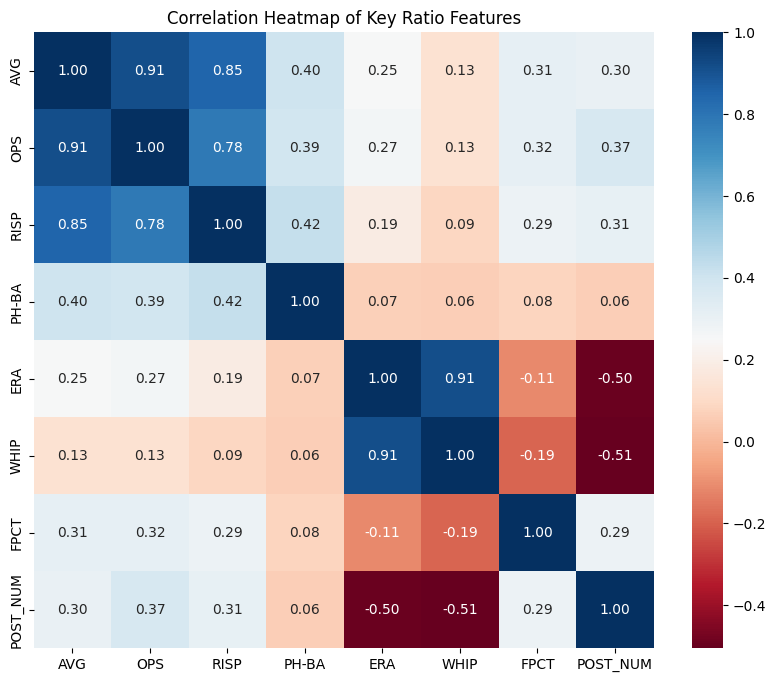

In [4]:
# Convert target variable to numeric
df['POST_NUM'] = df['POST'].apply(lambda x: 1 if x == 'Y' else 0)

# Select specified ratio features
features = ['AVG', 'OPS', 'RISP', 'PH-BA', 'ERA', 'WHIP', 'FPCT']

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[features + ['POST_NUM']].corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Correlation Heatmap of Key Ratio Features')
plt.show()

## 3. Data Preprocessing

Scaling and splitting the data into Training and Test sets.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[features]
y = df['POST_NUM']

# Split data (Stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (especially important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Training and Comparison

### 4.1 Logistic Regression (Baseline)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))

Logistic Regression Performance:
Accuracy: 0.7273
              precision    recall  f1-score   support

           0       0.78      0.64      0.70        11
           1       0.69      0.82      0.75        11

    accuracy                           0.73        22
   macro avg       0.74      0.73      0.72        22
weighted avg       0.74      0.73      0.72        22



### 4.2 Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))

Random Forest Performance:
Accuracy: 0.7727
              precision    recall  f1-score   support

           0       0.80      0.73      0.76        11
           1       0.75      0.82      0.78        11

    accuracy                           0.77        22
   macro avg       0.78      0.77      0.77        22
weighted avg       0.78      0.77      0.77        22



### 4.3 XGBoost

In [8]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("XGBoost Performance:")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(classification_report(y_test, xgb_preds))

XGBoost Performance:
Accuracy: 0.7727
              precision    recall  f1-score   support

           0       0.80      0.73      0.76        11
           1       0.75      0.82      0.78        11

    accuracy                           0.77        22
   macro avg       0.78      0.77      0.77        22
weighted avg       0.78      0.77      0.77        22



## 5. Summary and Feature Importance

<Figure size 1000x600 with 0 Axes>

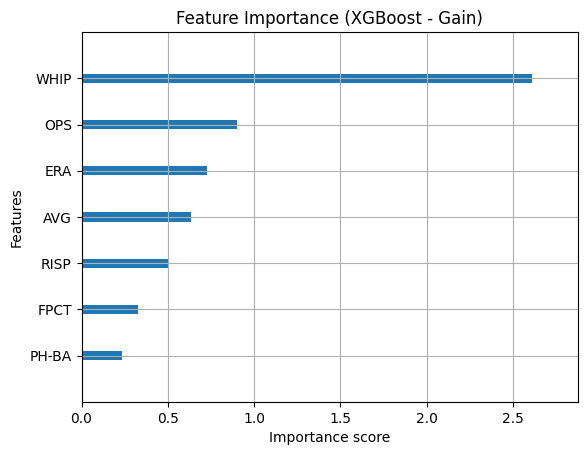

In [9]:
# Visualize XGBoost Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type='gain', show_values=False)
plt.title('Feature Importance (XGBoost - Gain)')
plt.show()

## Conclusion

Based on the results, the ensemble models (XGBoost/Random Forest) tend to perform well by capturing non-linear relationships. Factors like **OPS** and **ERA** are typically the strongest predictors of post-season advancement in KBO.